### understanding HOW CNNs actually see.

##### manual implementation of 
| Concept         | Why                        |
| --------------- | -------------------------- |
| convolution     | feature extraction         |
| kernels         | visual pattern detectors   |
| padding         | boundary preservation      |
| stride          | spatial compression        |
| pooling         | feature abstraction        |
| activation maps | CNN vision                 |
| edge detection  | primitive feature learning |

(by the end, deep understand)
    Image 
    → convolution
    → feature map
    → activation
    → pooling
    → hierarchical learning

1. Load image
2. Convert grayscale
3. Manual convolution
4. Apply kernels
5. Visualize feature maps
6. Stride experiment
7. Padding experiment
8. Pooling implementation
9. CNN intuition
10. Compare kernels

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from glob import glob

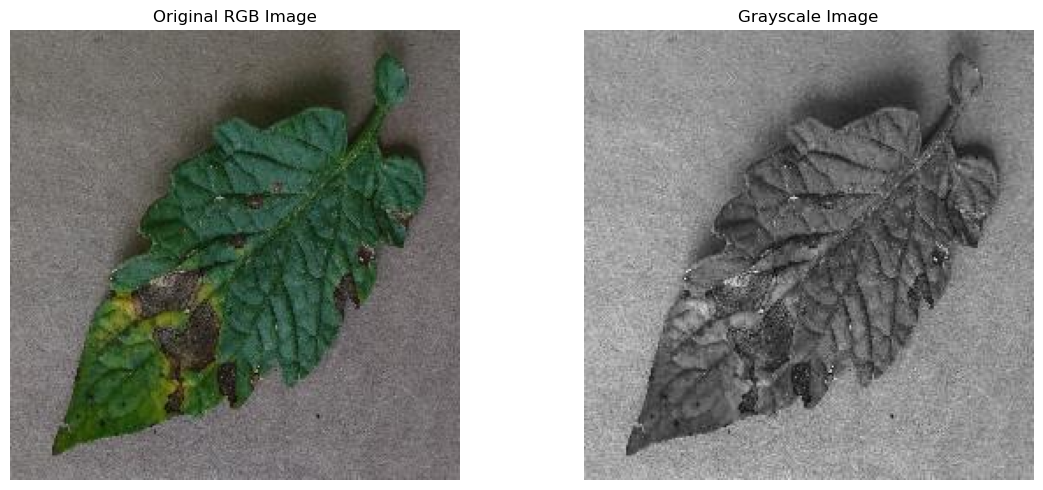

In [6]:
IMAGE_PATH = '../data/processed/tomato_subset/train/Tomato___Early_blight/ff422d28-d002-4382-80bf-30f78f66c677___RS_Erly.B 6492_flipTB.JPG'
# randomly select an image from the dataset

img = cv2.imread(IMAGE_PATH)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original RGB Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.tight_layout()

plt.show()

In [7]:
# ============================================================
# KERNELS
# ============================================================

vertical_kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

horizontal_kernel = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

sharpen_kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

blur_kernel = np.ones((3,3)) / 9

In [8]:
# ============================================================
# MANUAL CONVOLUTION
# ============================================================

def manual_convolution(image, kernel):

    image_h, image_w = image.shape

    kernel_h, kernel_w = kernel.shape

    output_h = image_h - kernel_h + 1
    output_w = image_w - kernel_w + 1

    output = np.zeros((output_h, output_w))

    # --------------------------------------------------------
    # Sliding Window
    # --------------------------------------------------------

    for i in range(output_h):
        for j in range(output_w):

            # local patch
            patch = image[
                i:i+kernel_h,
                j:j+kernel_w
            ]
            # element-wise multiplication
            value = np.sum(patch * kernel)
            output[i,j] = value

    return output

In [9]:
vertical_output = manual_convolution(
    img_gray,
    vertical_kernel
)

horizontal_output = manual_convolution(
    img_gray,
    horizontal_kernel
)

sharpen_output = manual_convolution(
    img_gray,
    sharpen_kernel
)

blur_output = manual_convolution(
    img_gray,
    blur_kernel
)

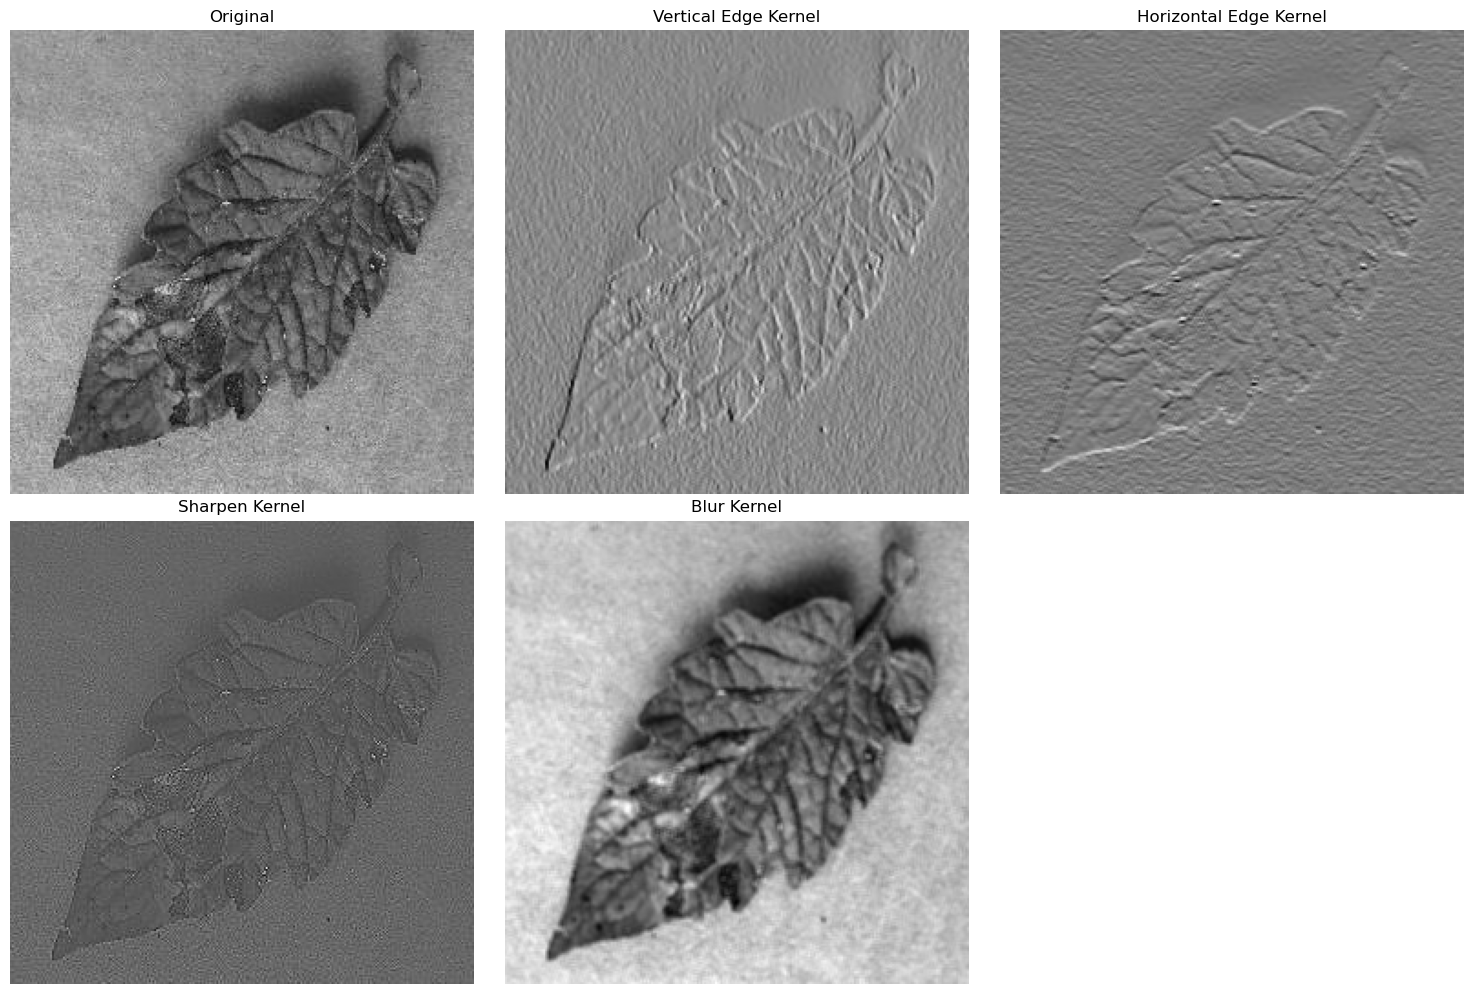

In [10]:
plt.figure(figsize=(15,10))

# ------------------------------------------------------------
# ORIGINAL
# ------------------------------------------------------------

plt.subplot(2,3,1)
plt.imshow(img_gray, cmap='gray')
plt.title("Original")
plt.axis("off")


# ------------------------------------------------------------
# VERTICAL
# ------------------------------------------------------------

plt.subplot(2,3,2)
plt.imshow(vertical_output, cmap='gray')
plt.title("Vertical Edge Kernel")
plt.axis("off")


# ------------------------------------------------------------
# HORIZONTAL
# ------------------------------------------------------------

plt.subplot(2,3,3)
plt.imshow(horizontal_output, cmap='gray')
plt.title("Horizontal Edge Kernel")
plt.axis("off")


# ------------------------------------------------------------
# SHARPEN
# ------------------------------------------------------------

plt.subplot(2,3,4)
plt.imshow(sharpen_output, cmap='gray')
plt.title("Sharpen Kernel")
plt.axis("off")


# ------------------------------------------------------------
# BLUR
# ------------------------------------------------------------

plt.subplot(2,3,5)
plt.imshow(blur_output, cmap='gray')
plt.title("Blur Kernel")
plt.axis("off")


plt.tight_layout()
plt.show()

In [11]:
def convolution_stride(image, kernel, stride=1):

    image_h, image_w = image.shape
    kernel_h, kernel_w = kernel.shape

    output_h = ((image_h - kernel_h) // stride) + 1
    output_w = ((image_w - kernel_w) // stride) + 1

    output = np.zeros((output_h, output_w))

    out_i = 0

    for i in range(0, image_h - kernel_h + 1, stride):
        out_j = 0
        for j in range(0, image_w - kernel_w + 1, stride):
            patch = image[i : i + kernel_h, j : j + kernel_w]
            output[out_i, out_j] = np.sum(patch * kernel)
            out_j += 1
        out_i += 1
    return output

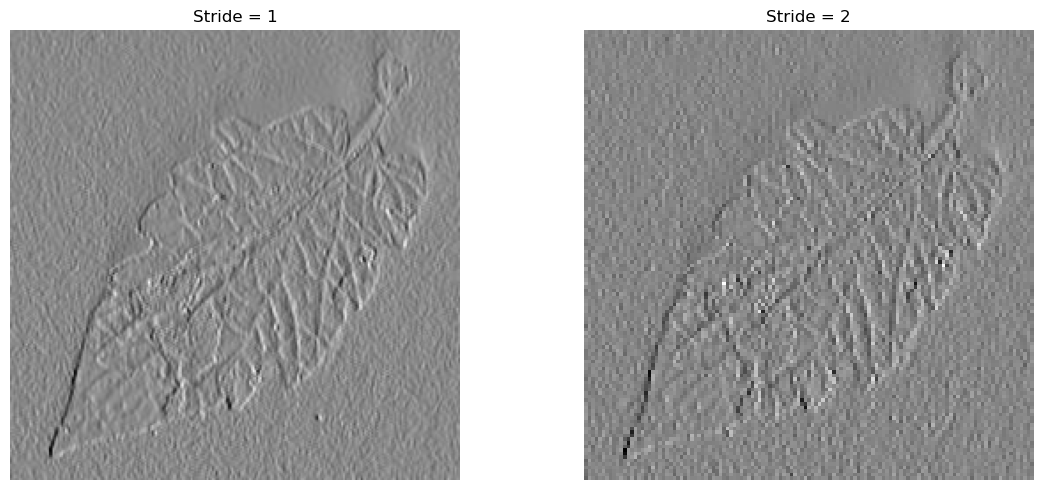

In [12]:
stride1 = convolution_stride(img_gray, vertical_kernel, stride=1)
stride2 = convolution_stride(img_gray, vertical_kernel, stride=2)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(stride1, cmap="gray")
plt.title("Stride = 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(stride2, cmap="gray")
plt.title("Stride = 2")
plt.axis("off")


plt.tight_layout()
plt.show()

##### OBSERVATION: Stride=2:

    compresses spatial information
    reduces computation
    sacrifices detail

# MAX POOLING:

    Pooling creates:
        spatial abstraction.
    
    Max pooling keeps:
        strongest activations.

        This creates:
            translation robustness
            dimensionality reduction
            feature abstraction

In [13]:
def max_pooling(image, size=2, stride=2):

    image_h, image_w = image.shape
    output_h = ((image_h - size) // stride) + 1
    output_w = ((image_w - size) // stride) + 1

    output = np.zeros((output_h, output_w))
    out_i = 0

    for i in range(0, image_h - size + 1, stride):
        out_j = 0
        for j in range(0, image_w - size + 1, stride):
            patch = image[i : i + size, j : j + size]
            output[out_i, out_j] = np.max(patch)
            out_j += 1
        out_i += 1

    return output

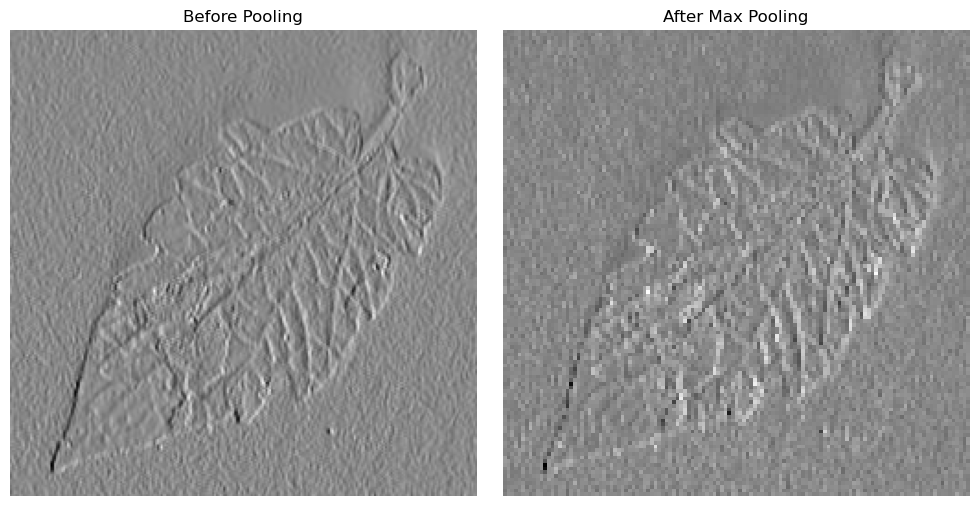

In [14]:
# APPLY POOLING
pooled = max_pooling(vertical_output)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(vertical_output, cmap='gray')
plt.title("Before Pooling")
plt.axis("off")


plt.subplot(1,2,2)
plt.imshow(pooled, cmap='gray')
plt.title("After Max Pooling")
plt.axis("off")

plt.tight_layout()
plt.show()

### OBSERVATION: 
    Pooling preserves:
        important activations

    while removing:
        redundancy
        
# CNN Feature Hierarchy

    Early Layers:
    - edges
    - gradients
    - color transitions

    Middle Layers:
    - spots
    - textures
    - lesions

    Deep Layers:
    - disease identity
    - pathology structure
    - complex visual semantics

    The manual convolution experiments above demonstrate how primitive visual detectors emerge from simple kernel operations.

### CNNs are fundamentally: learned hierarchical feature extractors.